In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
# Create date range
dates = pd.date_range(start="2024-01-01", periods=30)


In [4]:
# Create sample keywords
keywords = [f"keyword_{i}" for i in range(1, 21)]

In [5]:
# Generate data
data = []

In [6]:
#using random
for date in dates:
    for kw in keywords:
        impressions = np.random.randint(100, 1000)
        clicks = np.random.randint(10, impressions)
        ctr = clicks / impressions
        position = np.random.uniform(1, 50)
        
        data.append([date, kw, clicks, impressions, ctr, position])

In [7]:
# Create DataFrame
df = pd.DataFrame(data, columns=[
    "Date", "Keyword", "Clicks", "Impressions", "CTR", "Position"
])

In [8]:
#print it
df.head()

,Date,Keyword,Clicks,Impressions,CTR,Position
0,2024-01-01,keyword_1,84,126,0.666667,10.228714
1,2024-01-01,keyword_2,920,922,0.997831,44.382711
2,2024-01-01,keyword_3,141,879,0.160410,16.744764
3,2024-01-01,keyword_4,112,591,0.189509,19.649774
4,2024-01-01,keyword_5,130,774,0.167959,28.975013


In [9]:
# Shape of dataset
print("Shape:", df.shape)

Shape: (600, 6)


In [10]:
# Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         600 non-null    datetime64[us]
 1   Keyword      600 non-null    str           
 2   Clicks       600 non-null    int64         
 3   Impressions  600 non-null    int64         
 4   CTR          600 non-null    float64       
 5   Position     600 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 28.3 KB


In [11]:
#all the stats we need
df.describe()

,Date,Clicks,Impressions,CTR,Position
count,600,600.000000,600.000000,600.000000,600.000000
mean,2024-01-15 12:00:00,275.196667,549.850000,0.513967,25.364040
min,2024-01-01 00:00:00,10.000000,100.000000,0.013274,1.136987
25%,2024-01-08 00:00:00,100.000000,320.000000,0.270777,13.967270
50%,2024-01-15 12:00:00,220.000000,540.500000,0.512163,25.254073
75%,2024-01-23 00:00:00,393.750000,784.750000,0.762965,36.799547
max,2024-01-30 00:00:00,957.000000,999.000000,0.998926,49.967998
std,NaN,215.846885,267.587923,0.282631,13.989129


In [12]:
#check the number of keywords
print("Number of unique keywords:", df["Keyword"].nunique())
df["Keyword"].unique()[:10]

Number of unique keywords: 20


<StringArray>
[ 'keyword_1',  'keyword_2',  'keyword_3',  'keyword_4',  'keyword_5',
  'keyword_6',  'keyword_7',  'keyword_8',  'keyword_9', 'keyword_10']
Length: 10, dtype: str

In [13]:
total_clicks = df["Clicks"].sum()
total_impressions = df["Impressions"].sum()

In [14]:
# CTR calculation
average_ctr = total_clicks / total_impressions

In [15]:
average_position = df["Position"].mean()


In [16]:
print("Total Clicks:", total_clicks)

Total Clicks: 165118


In [17]:
print("Total Impressions:", total_impressions)

Total Impressions: 329910


In [18]:
print("Average CTR:", round(average_ctr, 4))


Average CTR: 0.5005


In [19]:
print("Average Position:", round(average_position, 2))

Average Position: 25.36


In [20]:
#creating a table to show all of this :)

kpi_df = pd.DataFrame({
    "Metric": ["Total Clicks", "Total Impressions", "Average CTR", "Average Position"],
    "Value": [total_clicks, total_impressions, average_ctr, average_position]
})

kpi_df

,Metric,Value
0,Total Clicks,165118.000000
1,Total Impressions,329910.000000
2,Average CTR,0.500494
3,Average Position,25.364040


In [21]:
#Checking the max and min CTR
print("Min CTR:", df["CTR"].min())
print("Max CTR:", df["CTR"].max())

Min CTR: 0.01327433628318584
Max CTR: 0.9989258861439313


In [22]:
#now to give position we can group them ny date and the sum of the clicks they have received
# Group by date and sum clicks
daily_clicks = df.groupby("Date")["Clicks"].sum().reset_index()

daily_clicks.head()

,Date,Clicks
0,2024-01-01,5329
1,2024-01-02,5474
2,2024-01-03,4923
3,2024-01-04,6659
4,2024-01-05,4632


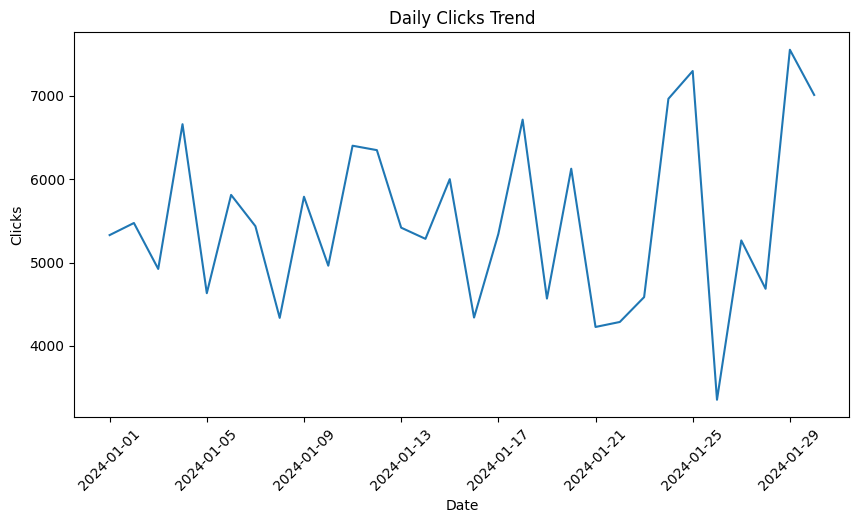

In [23]:
#plot now (line chart) import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(daily_clicks["Date"], daily_clicks["Clicks"])

plt.title("Daily Clicks Trend")
plt.xlabel("Date")
plt.ylabel("Clicks")
plt.xticks(rotation=45)

plt.show()


In [24]:
#cleanig since some key words are appearing multiple times
#we will combine them row wise
#this also will help us know which keyword has the most traffic

keyword_clicks = df.groupby("Keyword")["Clicks"].sum().reset_index()


In [25]:
keyword_clicks = keyword_clicks.sort_values(by="Clicks", ascending=False)

keyword_clicks.head()

,Keyword,Clicks
3,keyword_12,10901
1,keyword_10,10585
11,keyword_2,10287
6,keyword_15,9936
9,keyword_18,9873


In [26]:
#head of top 10 keywords
top_10_keywords=keyword_clicks.head(10)
top_10_keywords

,Keyword,Clicks
3,keyword_12,10901
1,keyword_10,10585
11,keyword_2,10287
6,keyword_15,9936
9,keyword_18,9873
13,keyword_3,8470
7,keyword_16,8412
5,keyword_14,8380
12,keyword_20,8225
8,keyword_17,8133


In [27]:
#bar for the keywords
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

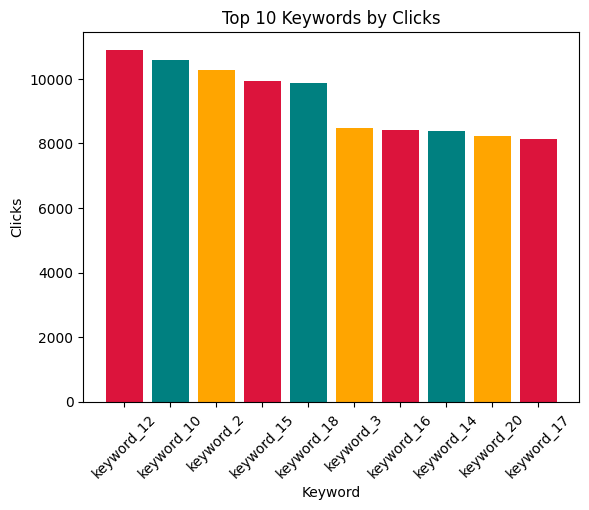

In [28]:
plt.bar(top_10_keywords["Keyword"], top_10_keywords["Clicks"], color=["crimson", "teal", "orange","crimson", "teal", "orange","crimson", "teal", "orange","Crimson"])
plt.title("Top 10 Keywords by Clicks")
plt.xlabel("Keyword")
plt.ylabel("Clicks")
plt.xticks(rotation=45)

plt.show()

In [29]:
#Opportunity Score=Impressions×(1−CTR)
#this means that high impression means lots of people see 
#low CTR means people do not click it

#this means that if a lot of people are seeing this but not clicking on it is a wasted potential. 
df["Opportunity_Score"] = df["Impressions"] * (1 - df["CTR"])

df.head()


,Date,Keyword,Clicks,Impressions,CTR,Position,Opportunity_Score
0,2024-01-01,keyword_1,84,126,0.666667,10.228714,42.0
1,2024-01-01,keyword_2,920,922,0.997831,44.382711,2.0
2,2024-01-01,keyword_3,141,879,0.160410,16.744764,738.0
3,2024-01-01,keyword_4,112,591,0.189509,19.649774,479.0
4,2024-01-01,keyword_5,130,774,0.167959,28.975013,644.0


In [30]:
keyword_opportunity=df.groupby("Keyword")["Opportunity_Score"].sum().reset_index()

In [31]:
#sort them in the descending order
keyword_opportunity=keyword_opportunity.sort_values(by="Opportunity_Score", ascending=False)
keyword_opportunity.head()

,Keyword,Opportunity_Score
2,keyword_11,10375.0
19,keyword_9,9747.0
14,keyword_4,9258.0
3,keyword_12,9161.0
18,keyword_8,9056.0


In [32]:
#best opportunites
best_opportunities=keyword_opportunity.head(10)
best_opportunities

,Keyword,Opportunity_Score
2,keyword_11,10375.0
19,keyword_9,9747.0
14,keyword_4,9258.0
3,keyword_12,9161.0
18,keyword_8,9056.0
15,keyword_5,8719.0
5,keyword_14,8556.0
9,keyword_18,8338.0
13,keyword_3,8325.0
17,keyword_7,8264.0


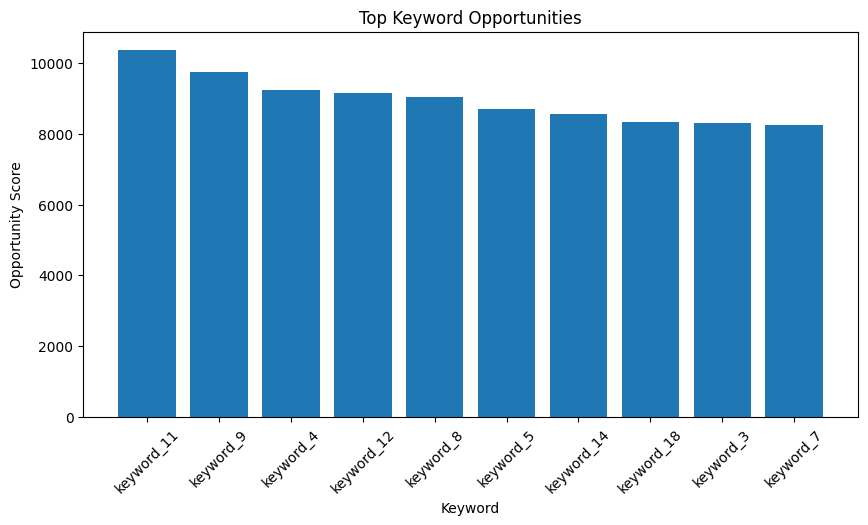

In [33]:
#plotting the opportunity chart
plt.figure(figsize=(10, 5))
plt.bar(best_opportunities["Keyword"], best_opportunities["Opportunity_Score"])
plt.title("Top Keyword Opportunities")
plt.xlabel("Keyword")
plt.ylabel("Opportunity Score")
plt.xticks(rotation=45)

plt.show()

In [34]:
#learning the model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly=PolynomialFeatures(degree=2)

In [35]:
daily_clicks["Day_Index"] = np.arange(len(daily_clicks))



In [36]:
X = daily_clicks[["Day_Index"]]
y = daily_clicks["Clicks"]

In [37]:
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
#predict for the next 7 days 

future_days=7
future_index = pd.DataFrame({
    "Day_Index": np.arange(len(daily_clicks), len(daily_clicks) + future_days)
})

# Apply SAME polynomial transform
future_index_poly = poly.transform(future_index)

predictions = model.predict(future_index_poly)

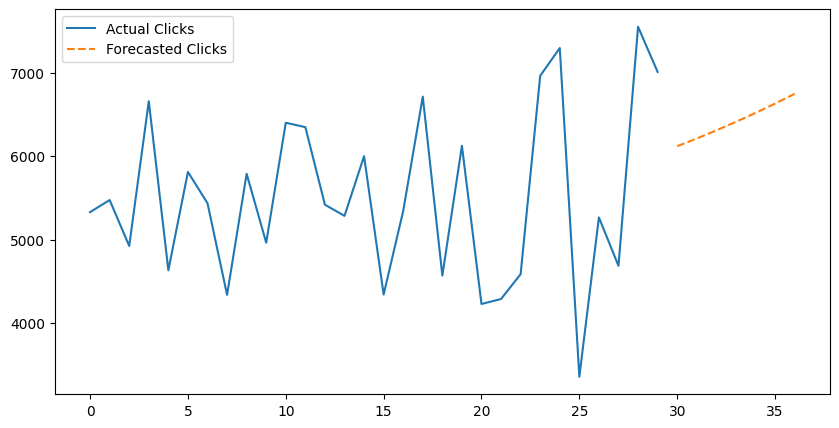

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(daily_clicks["Day_Index"], y, label="Actual Clicks")
plt.plot(future_index, predictions, linestyle="dashed", label="Forecasted Clicks")

plt.legend()
plt.show()

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on training data
y_pred = model.predict(X_poly)  # use X if linear / RF

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("R2 Score:", round(r2, 2))

MAE: 840.9
MSE: 1004041.04
R2 Score: 0.04
